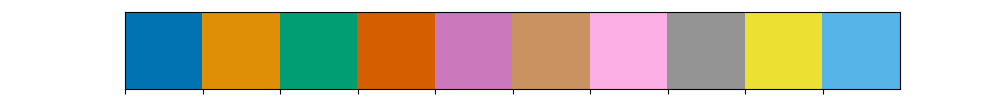

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy.coordinates import Angle
import astropy.units as u
import pickle
from astropy.io import fits

from matplotlib.colors import Normalize
from astropy.coordinates import SkyCoord

from scipy.interpolate import interp1d

pal = sns.color_palette("colorblind")

%matplotlib ipympl

sns.palplot(pal)

In [3]:
key = "crn"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (crn_track, crn_ha_fit_results, crn_hi_fit_results, 
                 crn_Ha_H_neg, crn_Ha_H_pos, crn_HI_H_neg, crn_HI_H_pos) = pickle.load(f)
    
key = "crf"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (crf_track, crf_ha_fit_results, crf_hi_fit_results, 
                 crf_Ha_H_neg, crf_Ha_H_pos, crf_HI_H_neg, crf_HI_H_pos) = pickle.load(f)
    
key = "per"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (per_track, per_ha_fit_results, per_hi_fit_results, 
                 per_Ha_H_neg, per_Ha_H_pos, per_HI_H_neg, per_HI_H_pos) = pickle.load(f)
    
key = "sgn"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (sgn_track, sgn_ha_fit_results, sgn_hi_fit_results, 
                 sgn_Ha_H_neg, sgn_Ha_H_pos, sgn_HI_H_neg, sgn_HI_H_pos) = pickle.load(f)
    
key = "sgf"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (sgf_track, sgf_ha_fit_results, sgf_hi_fit_results, 
                 sgf_Ha_H_neg, sgf_Ha_H_pos, sgf_HI_H_neg, sgf_HI_H_pos) = pickle.load(f)
    
key = "scn"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (scn_track, scn_ha_fit_results, scn_hi_fit_results, 
                 scn_Ha_H_neg, scn_Ha_H_pos, scn_HI_H_neg, scn_HI_H_pos) = pickle.load(f)
    

key = "ctn"
with open("FitResultsData/v2025/DECaPS_ExtinctionCorrected/{}_fit_results.pkl".format(key), 
          "rb") as f:
    (ctn_track, ctn_ha_fit_results, ctn_hi_fit_results, 
                 ctn_Ha_H_neg, ctn_Ha_H_pos, ctn_HI_H_neg, ctn_HI_H_pos) = pickle.load(f)    


In [4]:
hi_filename = "HI4PI_L4.5to352.5_B-10.0to10.0_ksz1080.0arcsec_sigmalim7.0_deltaL3.0_vLSR-200.0to200.0_commonlminusthres-1.8_V.fits"
with fits.open(hi_filename) as hdulist:
    hdulist.info()
    
    glon_grid = hdulist[0].data
    vlsr_grid = hdulist[1].data
    prs_grid = hdulist[2].data

Filename: HI4PI_L4.5to352.5_B-10.0to10.0_ksz1080.0arcsec_sigmalim7.0_deltaL3.0_vLSR-200.0to200.0_commonlminusthres-1.8_V.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  GLON          1 PrimaryHDU       8   (117, 311)   float64   
  1  vLSR          1 ImageHDU         9   (117, 311)   float64   
  2  Projected Rayleigh Statistic (V)    1 ImageHDU         9   (117, 311)   float64   


In [5]:
glon_grid_180 = Angle(glon_grid*u.deg).wrap_at("180d").value

glon_flat_360 = glon_grid.flatten()
glon_flat = glon_grid_180.flatten()
vlsr_flat = vlsr_grid.flatten()
prs_flat = prs_grid.flatten()

In [6]:
crn_vel_interpolator = interp1d(crn_track[:,0], crn_track[:,2], fill_value=np.nan, bounds_error=False)
crn_vel_smooth_ha = crn_vel_interpolator(glon_flat_360)

crf_vel_interpolator = interp1d(crf_track[:,0], crf_track[:,2], fill_value=np.nan, bounds_error=False)
crf_vel_smooth_ha = crf_vel_interpolator(glon_flat_360)

ctn_vel_interpolator = interp1d(ctn_track[:,0], ctn_track[:,2], fill_value=np.nan, bounds_error=False)
ctn_vel_smooth_ha = ctn_vel_interpolator(glon_flat_360)

per_vel_interpolator = interp1d(per_track[:,0], per_track[:,2], fill_value=np.nan, bounds_error=False)
per_vel_smooth_ha = per_vel_interpolator(glon_flat_360)

sgn_vel_interpolator = interp1d(sgn_track[:,0], sgn_track[:,2], fill_value=np.nan, bounds_error=False)
sgn_vel_smooth_ha = sgn_vel_interpolator(glon_flat_360)

sgf_vel_interpolator = interp1d(sgf_track[:,0], sgf_track[:,2], fill_value=np.nan, bounds_error=False)
sgf_vel_smooth_ha = sgf_vel_interpolator(glon_flat_360)

scn_vel_interpolator = interp1d(scn_track[:,0], scn_track[:,2], fill_value=np.nan, bounds_error=False)
scn_vel_smooth_ha = scn_vel_interpolator(glon_flat_360)


In [34]:
crn_rgal_interpolator = interp1d(crn_track[:,0], crn_track[:,3], fill_value=np.nan, bounds_error=False)
crn_rgal_smooth_prs = crn_rgal_interpolator(glon_flat_360)


crf_rgal_interpolator = interp1d(crf_track[:,0], crf_track[:,3], fill_value=np.nan, bounds_error=False)
crf_rgal_smooth_prs = crf_rgal_interpolator(glon_flat_360)

ctn_rgal_interpolator = interp1d(ctn_track[:,0], ctn_track[:,3], fill_value=np.nan, bounds_error=False)
ctn_rgal_smooth_prs = ctn_rgal_interpolator(glon_flat_360)

per_rgal_interpolator = interp1d(per_track[:,0], per_track[:,3], fill_value=np.nan, bounds_error=False)
per_rgal_smooth_prs = per_rgal_interpolator(glon_flat_360)

sgn_rgal_interpolator = interp1d(sgn_track[:,0], sgn_track[:,3], fill_value=np.nan, bounds_error=False)
sgn_rgal_smooth_prs = sgn_rgal_interpolator(glon_flat_360)

sgf_rgal_interpolator = interp1d(sgf_track[:,0], sgf_track[:,3], fill_value=np.nan, bounds_error=False)
sgf_rgal_smooth_prs = sgf_rgal_interpolator(glon_flat_360)

scn_rgal_interpolator = interp1d(scn_track[:,0], scn_track[:,3], fill_value=np.nan, bounds_error=False)
scn_rgal_smooth_prs = scn_rgal_interpolator(glon_flat_360)


In [93]:
# Track Masks

crn_mask = np.abs(crn_vel_smooth_ha - vlsr_flat) < 5.
crf_mask = np.abs(crf_vel_smooth_ha - vlsr_flat) < 5.
ctn_mask = np.abs(ctn_vel_smooth_ha - vlsr_flat) < 5.
per_mask = np.abs(per_vel_smooth_ha - vlsr_flat) < 5.
sgn_mask = np.abs(sgn_vel_smooth_ha - vlsr_flat) < 5.
sgf_mask = np.abs(sgf_vel_smooth_ha - vlsr_flat) < 5.
scn_mask = np.abs(scn_vel_smooth_ha - vlsr_flat) < 5.

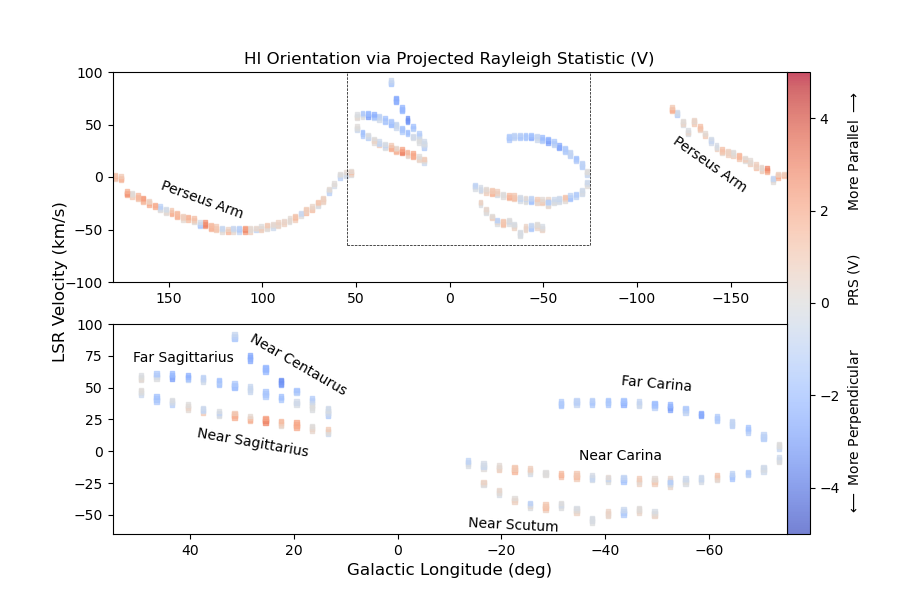

In [108]:
fig = plt.figure(constrained_layout=False, figsize = (9,6))
gs1 = fig.add_gridspec(nrows=2, ncols=60, wspace=0.0)
ax = fig.add_subplot(gs1[:-1, :-2])
cb_ax = fig.add_subplot(gs1[:, -2:])
ax2 = fig.add_subplot(gs1[-1,:-2])
# cb_ax2 = fig.add_subplot(gs1[-1, -2:])

ax2.set_xlabel("Galactic Longitude (deg)", fontsize = 12)
# ax.set_ylabel("LSR Velocity (km/s)", fontsize = 12)
ax2.set_ylabel("                                                        LSR Velocity (km/s)", fontsize = 12)

xlim = ax.set_xlim(180,-180)
ylim = ax.set_ylim(-100,100)

xlim = ax2.set_xlim(55,-75)
ylim = ax2.set_ylim(-65,100)

kwargs = {
    "vmin":-5,
    "vmax":5,
    "s":8,
    "marker":"s",
    "cmap":"coolwarm", "alpha":0.7
}

im = ax.scatter(glon_flat[crn_mask], vlsr_flat[crn_mask], c = prs_flat[crn_mask], 
                **kwargs)
plt.colorbar(im, cax = cb_ax, label = r"$\longleftarrow$ More Perpendicular          PRS (V)          More Parallel $\longrightarrow$")

im = ax.scatter(glon_flat[crf_mask], vlsr_flat[crf_mask], c = prs_flat[crf_mask], 
                **kwargs)

im = ax.scatter(glon_flat[ctn_mask], vlsr_flat[ctn_mask], c = prs_flat[ctn_mask], 
                **kwargs)

im = ax.scatter(glon_flat[per_mask], vlsr_flat[per_mask], c = prs_flat[per_mask], 
                **kwargs)

im = ax.scatter(glon_flat[sgn_mask], vlsr_flat[sgn_mask], c = prs_flat[sgn_mask], 
                **kwargs)

im = ax.scatter(glon_flat[sgf_mask], vlsr_flat[sgf_mask], c = prs_flat[sgf_mask], 
                **kwargs)

im = ax.scatter(glon_flat[scn_mask], vlsr_flat[scn_mask], c = prs_flat[scn_mask], 
                **kwargs)



# Annotations

ax.plot(xlim, [ylim[0],ylim[0]], lw = 0.5, ls = "--", color = "k")
ax.plot(xlim, [ylim[1],ylim[1]], lw = 0.5, ls = "--", color = "k")
ax.plot([xlim[0],xlim[0]], ylim, lw = 0.5, ls = "--", color = "k")
ax.plot([xlim[1],xlim[1]], ylim, lw = 0.5, ls = "--", color = "k")


ax2.text(-50,45,"Far Carina", ha="center", va = "bottom", fontsize = 10, rotation = -5)
ax2.text(-35,-9,"Near Carina", ha="left", va = "bottom", fontsize = 10)

ax2.text(-31,-51,"Near Scutum", ha="right", va = "top", fontsize = 10, rotation = -3)

ax2.text(17,20,"Near Sagittarius", ha="right", va = "top", fontsize = 10, rotation = -10)
ax2.text(51,68,"Far Sagittarius", ha="left", va = "bottom", fontsize = 10)

ax2.text(29,94,"Near Centaurus", ha="left", va = "top", fontsize = 10, rotation = -30)


ax.text(155,-2,"Perseus Arm", ha="left", va = "top", fontsize = 10, rotation = -20)
ax.text(-118,41,"Perseus Arm", ha="left", va = "top", fontsize = 10, rotation = -35)

kwargs["s"] = 10

im = ax2.scatter(glon_flat[crn_mask], vlsr_flat[crn_mask], c = prs_flat[crn_mask], 
                **kwargs)

im = ax2.scatter(glon_flat[crf_mask], vlsr_flat[crf_mask], c = prs_flat[crf_mask], 
                **kwargs)

im = ax2.scatter(glon_flat[ctn_mask], vlsr_flat[ctn_mask], c = prs_flat[ctn_mask], 
                **kwargs)

im = ax2.scatter(glon_flat[sgn_mask], vlsr_flat[sgn_mask], c = prs_flat[sgn_mask], 
                **kwargs)

im = ax2.scatter(glon_flat[sgf_mask], vlsr_flat[sgf_mask], c = prs_flat[sgf_mask], 
                **kwargs)

im = ax2.scatter(glon_flat[scn_mask], vlsr_flat[scn_mask], c = prs_flat[scn_mask], 
                **kwargs)

ax.set_title(r"HI Orientation via Projected Rayleigh Statistic (V)", fontsize = 12)


fig.savefig("Figures/v2025/LV_PRS.png", 
            dpi = 300, 
            transparent = True)
fig.savefig("Figures/v2025/LV_PRS.svg", 
#             dpi = 300, 
            transparent = True)

In [100]:
# Track Masks

crn_mask = np.abs(crn_vel_smooth_ha - vlsr_flat) < 2.5
crf_mask = np.abs(crf_vel_smooth_ha - vlsr_flat) < 2.5
ctn_mask = np.abs(ctn_vel_smooth_ha - vlsr_flat) < 2.5
per_mask = np.abs(per_vel_smooth_ha - vlsr_flat) < 2.5
sgn_mask = np.abs(sgn_vel_smooth_ha - vlsr_flat) < 2.5
sgf_mask = np.abs(sgf_vel_smooth_ha - vlsr_flat) < 2.5
scn_mask = np.abs(scn_vel_smooth_ha - vlsr_flat) < 2.5

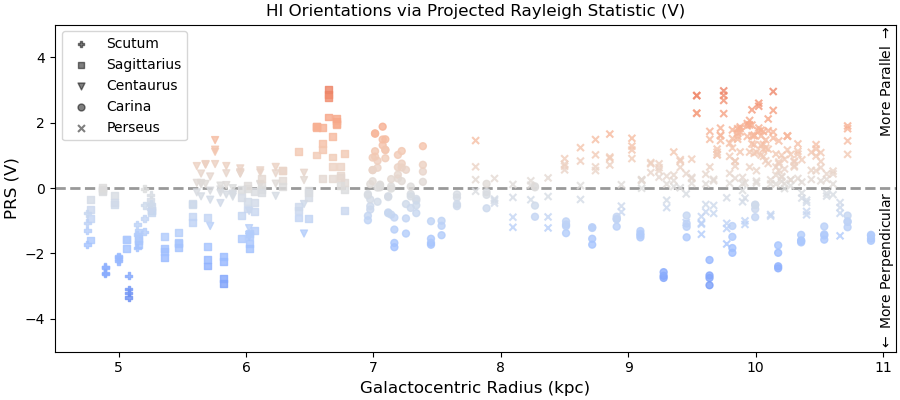

In [107]:
fig = plt.figure(figsize = (9,4), constrained_layout = True)

ax2 = fig.add_subplot(111)
# ax2 = ax.twinx()


# ax.set_ylabel("$H_{{N_{{HI}}}}$ (kpc)", fontsize = 12)
ax2.set_ylabel("PRS (V)", fontsize = 12)
kwargs = {
    "alpha":0.8,
    "vmin":-5,
    "vmax":+5,
    "cmap":"coolwarm", 
    "s":25
}

# Carina Near
ax2.scatter(crn_rgal_smooth_prs[crn_mask], prs_flat[crn_mask], c = prs_flat[crn_mask], **kwargs, marker = "o")
# Carina Far
ax2.scatter(crf_rgal_smooth_prs[crf_mask], prs_flat[crf_mask], c  = prs_flat[crf_mask], marker = "o", **kwargs)


# # Centaurus Near
ax2.scatter(ctn_rgal_smooth_prs[ctn_mask], prs_flat[ctn_mask], c = prs_flat[ctn_mask], marker = "v", **kwargs)


# # Sag Near
ax2.scatter(sgn_rgal_smooth_prs[sgn_mask], prs_flat[sgn_mask], c = prs_flat[sgn_mask], marker = "s", **kwargs)
# # Sag Far
ax2.scatter(sgf_rgal_smooth_prs[sgf_mask], prs_flat[sgf_mask], c = prs_flat[sgf_mask], marker = "s", **kwargs)

# # Scutum Near
ax2.scatter(scn_rgal_smooth_prs[scn_mask], prs_flat[scn_mask], c = prs_flat[scn_mask], marker = "P", **kwargs)

# # Perseus Near
ax2.scatter(per_rgal_smooth_prs[per_mask], prs_flat[per_mask], c = prs_flat[per_mask], marker = "x", **kwargs)


xlim = ax2.get_xlim()
# Fake Points for legend
ax2.scatter([0],[0], marker = "P", label = "Scutum", s = 25, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "s", label = "Sagittarius", s = 25, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "v", label = "Centaurus", s = 25, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "o", label = "Carina", s = 25, color = "k", alpha = 0.5)
ax2.scatter([0],[0], marker = "x", label = "Perseus", s = 25, color = "k", alpha = 0.5)

lg = ax2.legend(fontsize = 10)

ax2.set_xlim(4.5,11.1)
ax2.set_ylim(-5, 5)

ax2.axhline(0, ls = "--", lw = 2, alpha = 0.4, zorder = -1, color = "k")

ax2.set_xlabel("Galactocentric Radius (kpc)", fontsize = 12)
ax2.set_title(r"HI Orientations via Projected Rayleigh Statistic (V)", fontsize = 12)

ax2.text(11.1, 0, r"$\leftarrow$ More Perpendicular             More Parallel $\rightarrow$", ha = "right", va = "center", fontsize = 10, rotation = 90)

fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_PRS.png", 
            dpi = 300, 
            transparent = True)
fig.savefig("Figures/v2025/ScaleHeight+MidplaneIntensity_Plots/RGal_PRS.svg", 
#             dpi = 300, 
            transparent = True)